In [1]:
import jax
import jax.numpy as jnp

jax.config.update('jax_enable_x64', True)

In [2]:
from pathlib import Path

import astropy.units as u
import croissant as cro
import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
import scipy.sparse.linalg as sla
from astropy.time import Time

import mistsim as ms

%matplotlib widget

## 1. Define simulation

In [3]:
DATA_DIR = Path(
    "/home/christian/Documents/research/MIST/mistsim/data/"
)

# beam
d = np.load(DATA_DIR / Path("beam.npz"))
freqs = d["freqs"]
gain = d["gain"]
theta = d["theta"]
horizon = theta <= np.deg2rad(80)
print(gain.shape, horizon.shape)

# sky
d = np.load(DATA_DIR / Path("haslam_galactic.npz"))
haslam = d["m"]
nside = d["nside"].item()
assert np.allclose(freqs, d["freqs"])  # check freqs match
print(haslam.shape, nside)

# this is the frequency of the simulation
FREQ_IX = -1
sim_freq = freqs[FREQ_IX]
print(f"Simulation frequency = {sim_freq:.0f} MHz")

# beam and sky at the frequency, need to add a dimension for broadcating
g = gain[FREQ_IX]
beam = ms.Beam(g[None], sim_freq, sampling="mwss", horizon=horizon[:, None])

sky_map = haslam[FREQ_IX]
sky = ms.Sky(sky_map[None], sim_freq, sampling="healpix", coord="galactic")

# forward sim params
tstart = Time("2026-02-25 12:27")
tend = tstart + 1*u.sday  # one sidereal day
times = cro.utils.time_array(t_start=tstart, t_end=tend, N_times=500)

lon = -90.74750
lat = 79.41833
alt = 150
lmax = 75

sim = ms.Simulator(beam, sky, times.jd, sim_freq, lon, lat, alt=alt, lmax=lmax)
A = ms.mapmaking.make_Amat(sim)

# create x vector
sky_alm = sky.compute_alm_eq(world="earth")
sky_alm = cro.utils.reduce_lmax(sky_alm, lmax)
x = ms.mapmaking.pack_s2fft_to_real(sky_alm)

(86, 181, 360) (181,)
(86, 196608) 128
Simulation frequency = 125 MHz


In [4]:
def alm1d_to_hp(alm):
    """
    Convert alm 1d with real/imag parts to healpy ordering
    """
    s = len(alm)  # one freq only for now
    lmax = int(np.sqrt(s) - 1)
    hp_len = hp.Alm.getsize(lmax)
    alm0 = alm[:lmax+1]
    almre = alm[lmax+1:hp_len]
    almim = alm[hp_len:]
    almc = 1/np.sqrt(2) * (almre + 1j*almim)
    return jnp.concatenate((alm0, almc))

x_hp = alm1d_to_hp(x)

## 2. Run simulation, define noise and prior

In [5]:
y = A@x

# noise: radiometer
df = (freqs[1] - freqs[0]) * 1e6
dt = (times[1] - times[0]).to_value(u.s)
print(dt * df)
sigma = y.real / np.sqrt(dt * df)
Ndiag = sigma**2  # diag matrix

rng = np.random.default_rng(seed=1420)
noise = rng.normal(loc=0, scale=sigma)

172673528.11623126


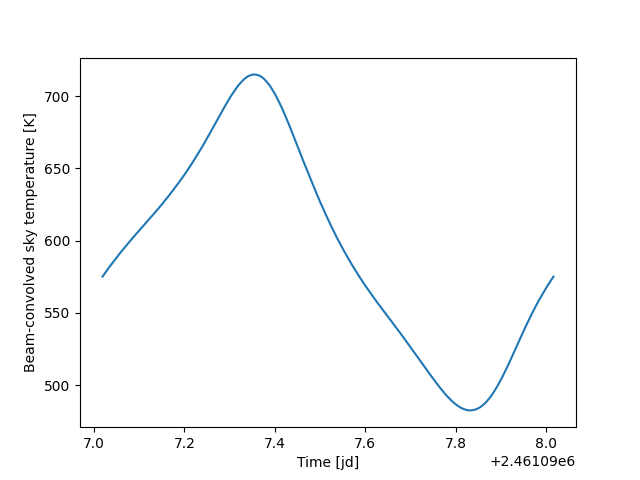

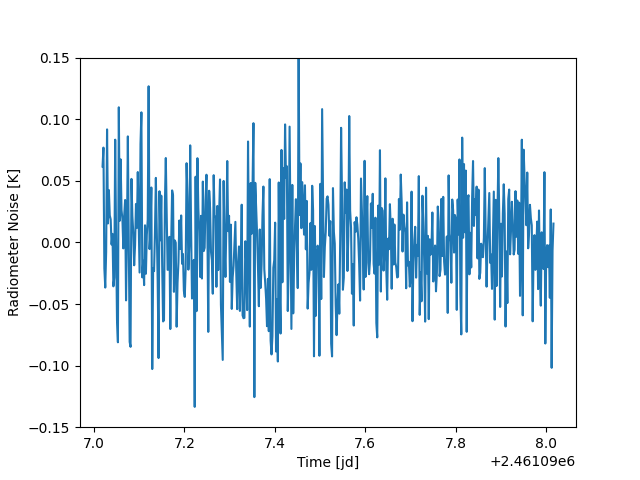

In [6]:
plt.figure()
plt.plot(times.jd, y+noise)
plt.xlabel("Time [jd]")
plt.ylabel("Beam-convolved sky temperature [K]")
plt.show()
plt.figure()
plt.plot(times.jd, noise)
plt.ylim(-0.15, 0.15)
plt.ylabel("Radiometer Noise [K]")
plt.xlabel("Time [jd]")
plt.show()

In [7]:
def prior_th(x, eps):
    """
    Thikonov regularization prior, S = eps*I

    Parameters
    ----------
    eps : float
    x : jax.Array
        True sky.

    Returns
    -------
    Sdiag : ndarray
        The diagonal of S

    """
    Sdiag = eps * np.ones(len(x))
    return Sdiag

def prior_ps(x):
    """
    Make prior be the true power spectrum of the sky

    Parameters
    ----------
    x : array_like
        Column vector

    """
    xhp = np.asarray(alm1d_to_hp(x))
    cl = hp.alm2cl(xhp)
    ells_hp, emms_hp = hp.Alm.getlm(lmax)
    ells_pos = ells_hp[emms_hp != 0]
    ells_full = np.concatenate((ells_hp, ells_pos))  # the m>=0 comes twice
    cl_full = cl[ells_full]
    return cl_full

Sdiag = prior_ps(x)
SAH = ms.mapmaking.make_SAH(Sdiag, A)  # this is S @ A^H

# this is the matrix to invert
I_m = np.eye(A.shape[0], dtype=A.dtype)
M = (A @ SAH) @ I_m + np.diag(Ndiag)
Minv = np.linalg.inv(M)

In [8]:
xhat = SAH @ Minv @ (y+noise)
yr = np.real(A @ xhat)

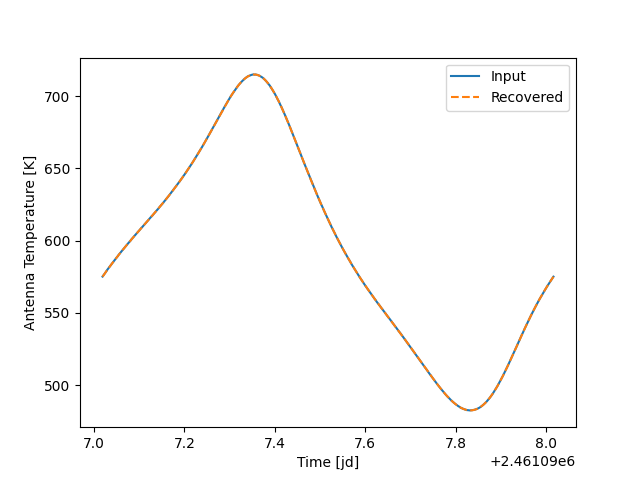

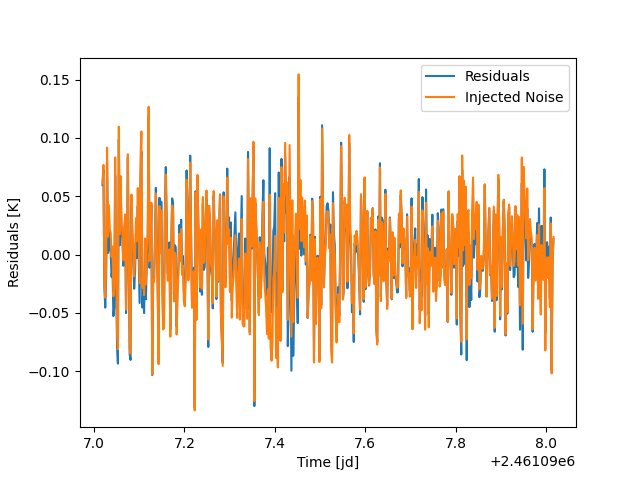

In [9]:
plt.figure()
plt.plot(times.jd, y+noise, label="Input")
plt.plot(times.jd, y, ls="--", label="Recovered")
plt.legend()
plt.xlabel("Time [jd]")
plt.ylabel("Antenna Temperature [K]")
plt.show()

plt.figure()
plt.plot(times.jd, y+noise-yr, label="Residuals")
plt.plot(times.jd, noise, label="Injected Noise")
plt.legend()
plt.xlabel("Time [jd]")
plt.ylabel("Residuals [K]")
plt.show()

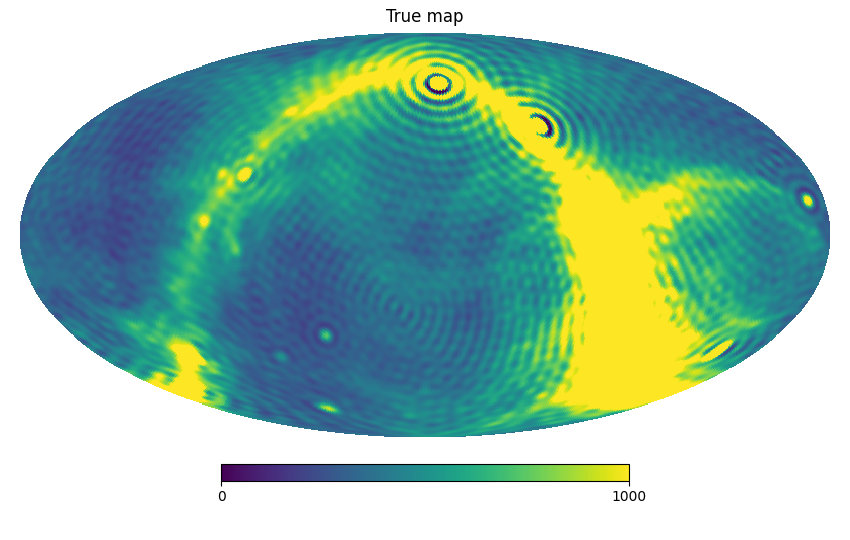

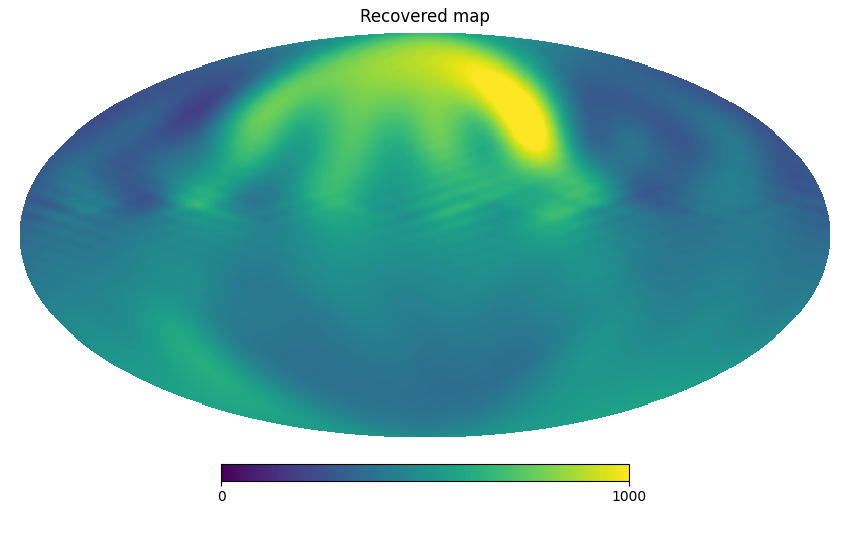

In [10]:
xhat_hp = alm1d_to_hp(xhat)
xhatm = hp.alm2map(xhat_hp, nside)
hp.mollview(hp.alm2map(x_hp, nside), title="True map", min=0, max=1000)
plt.show()
hp.mollview(xhatm, title="Recovered map", min=0, max=1000)
plt.show()

## Understanding the Wiener filter

We started with the linear equation
$$\mathbf{y} = \mathbf{A}\mathbf{x} + \mathbf{n},$$
and found that, under our assumptions of the noise covariance $\mathbf{N}$ and signal prior covariance $\mathbf{S}$, the optimal estimator is
$$\mathbf{\hat{x}} = \mathbf{W} \mathbf{y},$$
with the Wiener filter defined as
$$\mathbf{W} = \left(\mathbf{A^H}\mathbf{N}^{-1}\mathbf{A}+\mathbf{S}^{-1}\right)^{-1}\mathbf{A^H}\mathbf{N}^{-1}$$. 

This is equivalent to solving the linear least squares in a rotated vector space
$$\mathbf{\tilde{y}} = \mathbf{\tilde{A}}\mathbf{\tilde{x}},$$
with
$$\mathbf{\tilde{y}} = \mathbf{N}^{-1/2}\mathbf{y},$$
$$\mathbf{\tilde{A}} = \mathbf{N}^{-1/2}\mathbf{A}\mathbf{S}^{1/2},$$
$$\mathbf{\tilde{x}} = \mathbf{S}^{-1/2}\mathbf{x}.$$
In the rotated vector space, the data is whitened by the covariance matrices describing the noise and the prior on the signal, meaning that the noise and signal covariance in this space are both the identity matrix.

In this space, the optimal mapmaker is given by
$$\mathbf{\tilde{\hat{x}}} = \mathbf{\tilde{W}}\mathbf{\tilde{y}},$$

$$\mathbf{\tilde{W}} = \left(\mathbf{\tilde{A}^H}\mathbf{\tilde{A}}+\mathbf{I}\right)^{-1}\mathbf{\tilde{A}^H}.$$

In our new form, we can do a singular value decomposition on $\mathbf{\tilde{A}}= \mathbf{U} \mathbf{\Sigma} \mathbf{V}^H$ to get
$$\mathbf{\tilde{W}} = \left(\mathbf{V}\mathbf{\Sigma}^2 \mathbf{V}^H+\mathbf{I}\right)^{-1}\mathbf{V}\mathbf{\Sigma}\mathbf{U}^H,$$
$$\mathbf{\tilde{W}} = \left(\mathbf{V}\left(\mathbf{\Sigma}^2+\mathbf{I}\right) \mathbf{V}^H\right)^{-1}\mathbf{V}\mathbf{\Sigma}\mathbf{U}^H,$$
$$\mathbf{\tilde{W}} = \mathbf{V}\left(\mathbf{\Sigma}^2+\mathbf{I}\right)^{-1} \mathbf{\Sigma}\mathbf{U}^H.$$

$\mathbf{\Sigma}$ is a diagonal matrix of singular values, we write $\Sigma_{ii} = \sigma_i$ where $\sigma_i$ is the i-th singular value. We can therefore write
$$\mathbf{\tilde{W}} = \mathbf{V}\mathbf{D}\mathbf{U}^H,$$
with
$$\mathbf{D} = \left(\mathbf{\Sigma}^2+\mathbf{I}\right)^{-1} \mathbf{\Sigma},$$
$$D_{ii}= \frac{\sigma_i}{1+\sigma_i^2}.$$

We know have a very powerful method to understand the constraining power of our map. Here's the recipe: Rotate the design matrix $\mathbf{A}$ into the whitened space $\mathbf{\tilde{A}}$, compute the singular value decomposition in this space, and create the diagonal filter coefficient matrix $\mathbf{D}$. The singular values directly represent the signal-to-noise ratio (SNR). Large singular values essentially gives a pseudo-inverse ($1/\sigma$-weights) while small singular values weights data by $\sigma$ and trust the priors more.

True


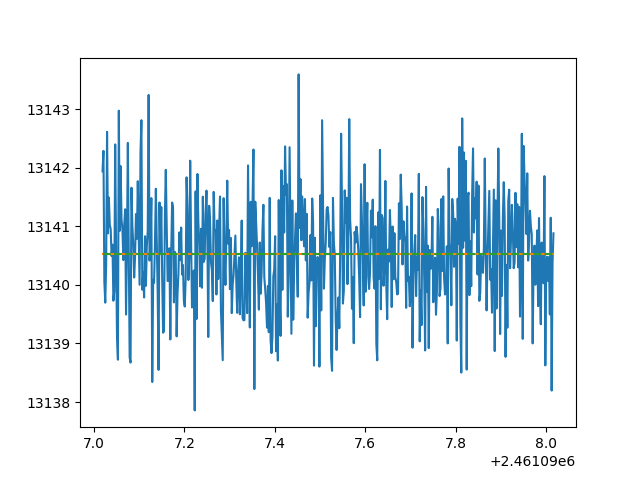

In [11]:
Atilde = ms.mapmaking.make_Atilde(Ndiag, A, Sdiag)
U_full, Sigma, Vh_full = sla.svds(Atilde, k=200)

# sort the u, s, v
svd_ix = np.argsort(Sigma)[::-1]
U_full = U_full[:, svd_ix]
Sigma = Sigma[svd_ix]
Vh_full = Vh_full[svd_ix]

xtilde = Sdiag**(-1/2) * x
ytilde = Ndiag**(-1/2) * y
ntilde = Ndiag**(-1/2) * noise

# confirm we got Ax = y still
print(np.allclose(Atilde @ xtilde, ytilde))

plt.figure()
plt.plot(times.jd, ytilde+ntilde)
plt.plot(times.jd, ytilde)
plt.plot(times.jd, Atilde@xtilde, ls="--")
plt.show()

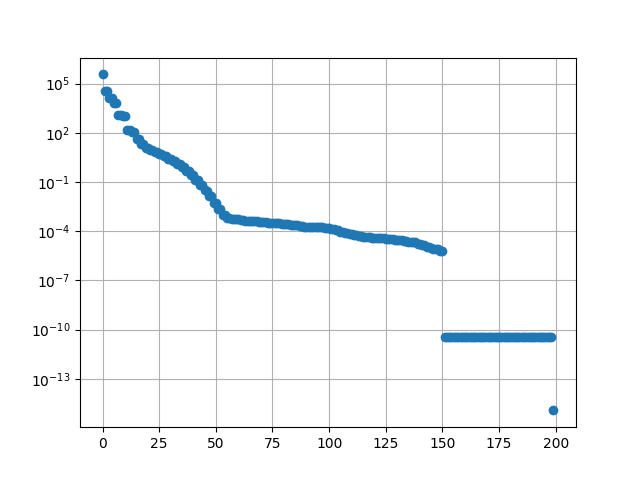

In [12]:
plt.figure()
plt.plot(Sigma, ls="none", marker="o")
plt.yscale("log")
plt.grid()
plt.show()

Based on the figure, we can safely set vectors after 151 to 0.

In [13]:
print(Sigma[150], Sigma[151])

6.156759785157512e-06 3.6525532412882564e-11


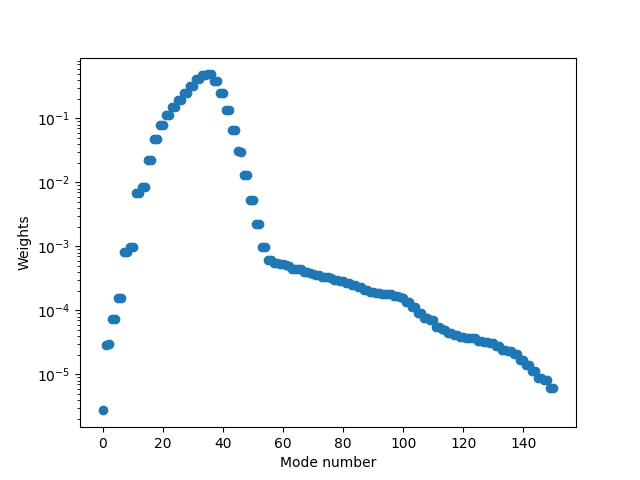

In [14]:
nvec = 151
Dnum = Sigma[:nvec]
Dden = 1 + Dnum**2
D = Dnum / Dden
U = U_full[:, :nvec]
Vh = Vh_full[:nvec]

plt.figure()
plt.plot(np.arange(nvec), D[:nvec], ls="none", marker="o")
plt.ylabel("Weights")
plt.xlabel("Mode number")
plt.yscale("log")
plt.show()

In [15]:
W_tilde = Vh.T @ np.diag(D) @ U.T  # VDU^T
y_tilde = Ndiag**(-1/2) * (y+noise)
x_tilde = W_tilde @ y_tilde

In [16]:
xh_svd = Sdiag**(1/2) * x_tilde
xh_svd_hp = alm1d_to_hp(xh_svd)

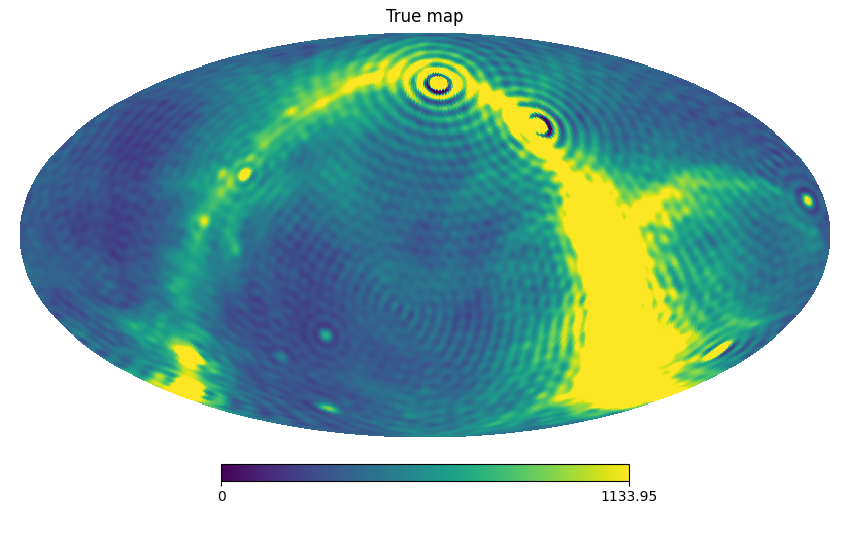

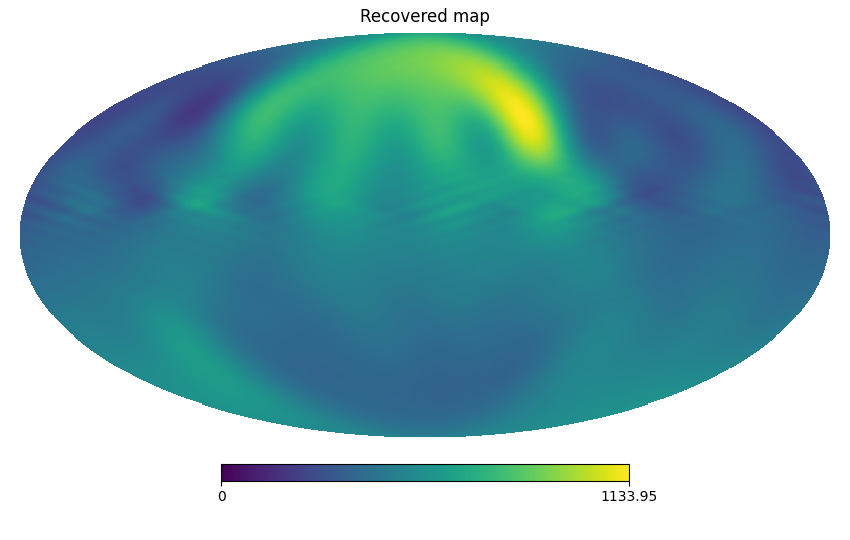

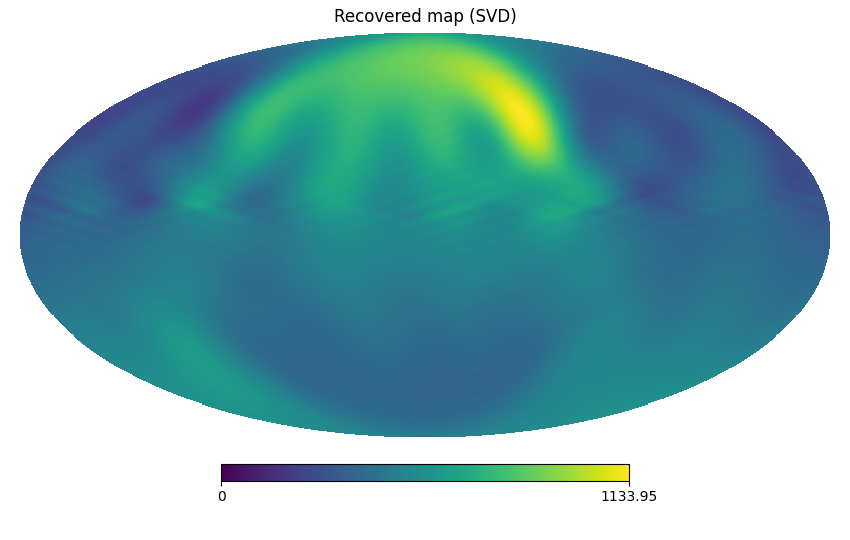

In [17]:
best_map = hp.alm2map(xh_svd_hp, nside)
vmax = best_map.max()

hp.mollview(hp.alm2map(x_hp, nside), title="True map", min=0, max=vmax)
plt.show()
hp.mollview(
    hp.alm2map(xhat_hp, nside), title="Recovered map", min=0, max=vmax
)
plt.show()
hp.mollview(best_map, title="Recovered map (SVD)", min=0, max=vmax)
plt.show()

## What information did we gain?

In [18]:
nvar = 1000

# generate 1000 random alm's
wfull = np.random.normal(size=(Atilde.shape[1], nvar))  # variance = 1

# compute the posterior standard deviation in the SVD basis
post_std_svd = 1.0 / np.sqrt(Dnum**2 + 1.0)  # 1/(sigma**2+1)
std_reduce = 1 - post_std_svd  # this is reduced variance in posterior

# compute reduced-variance noise
corr = Vh.T @ (std_reduce[:, None] * (Vh @ wfull))
x_tilde_sim = wfull - corr  # subtract corection

# back to harmonic coefficients
x_sim = np.sqrt(Sdiag)[:, None] * x_tilde_sim
x_sim_hp = np.array(
    [
        hp.alm2map(
            alm1d_to_hp(x_sim[:, i]), nside
        ) for i in range(x_sim.shape[-1])
    ]
)

In [19]:
std_map = np.std(x_sim_hp, axis=0)

In [20]:
# prior power spectrum
cl_prior = hp.alm2cl(np.asarray(x_hp))

ell = np.arange(len(cl_prior))
sigma2_prior = np.sum((2 * ell + 1) / (4 * np.pi) * cl_prior)

print(f"Prior standard deviation = {np.sqrt(sigma2_prior):.1f} K")

Prior standard deviation = 993.8 K


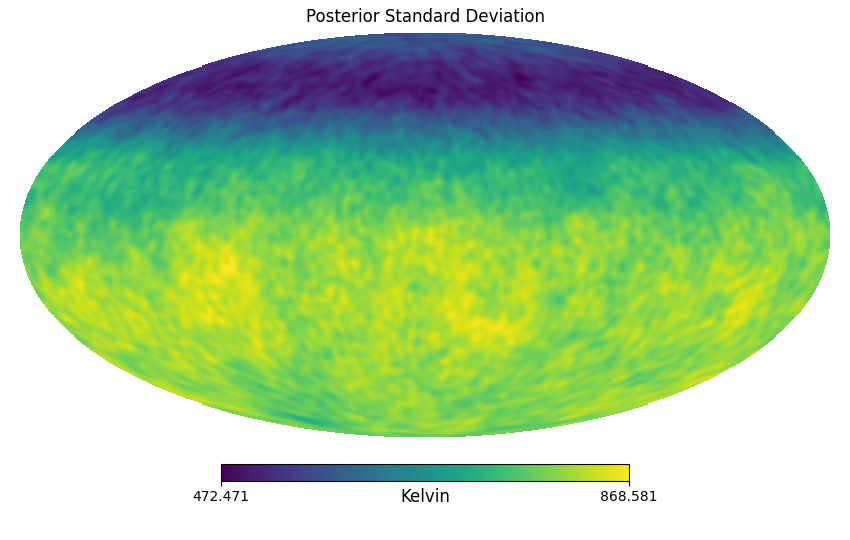

In [21]:
hp.mollview(std_map, title="Posterior Standard Deviation", unit="Kelvin")
plt.show()

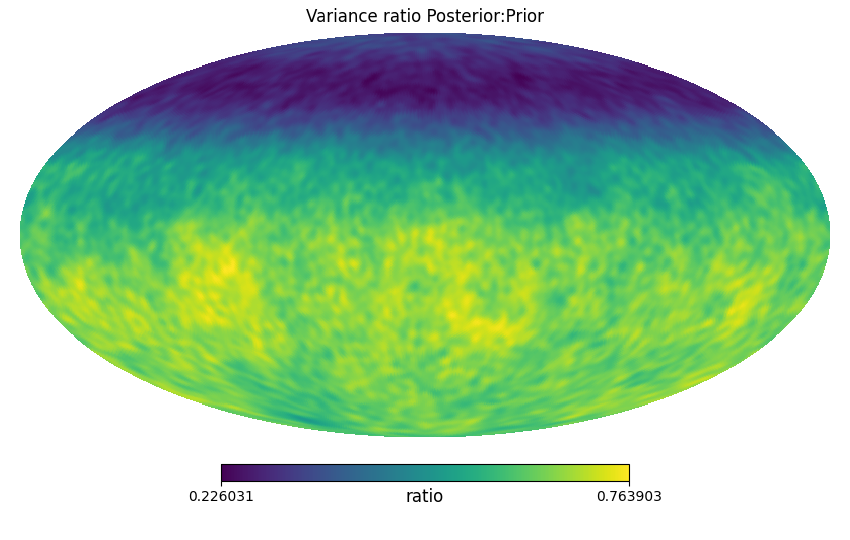

In [22]:
hp.mollview(
    std_map**2/sigma2_prior,
    title="Variance ratio Posterior:Prior",
    unit="ratio",
)
plt.show()

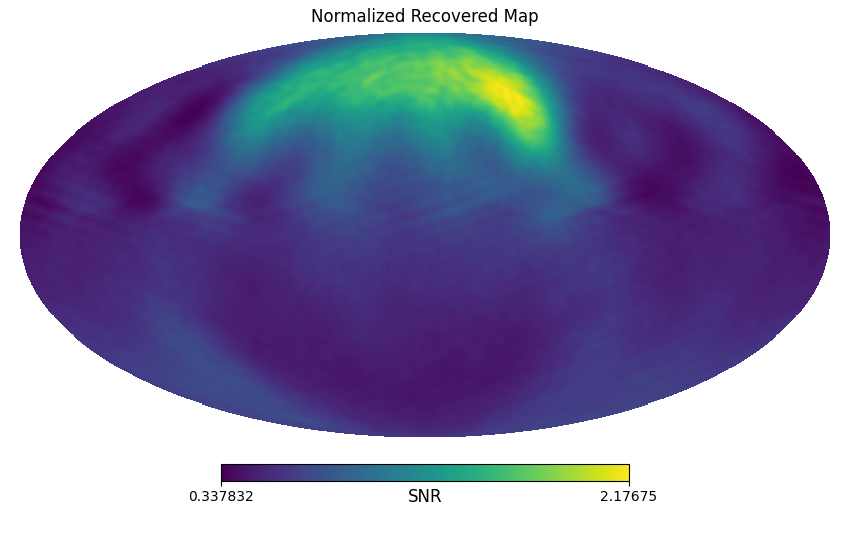

In [23]:
hp.mollview(best_map/std_map, title="Normalized Recovered Map", unit="SNR")
plt.show()